In [1]:
import os
import pandas
import matplotlib.pyplot as plt
import numpy as np

In [4]:

import glob
folder_path = "../MarketData/historical_data"
files = glob.glob(os.path.join(folder_path, "spy_1min_*.csv"))
dfs = []
for file in files:
    df = pandas.read_csv(file).sort_values("ts_recv").reset_index(drop=True)
    df["prev_ret_60s"] = df["ret_60s"].shift(1)
    dfs.append(df)
print(len(dfs))
data = pandas.concat(dfs)
data["ret_60s"] *= 100
data["prev_ret_60s"] *= 100

1899


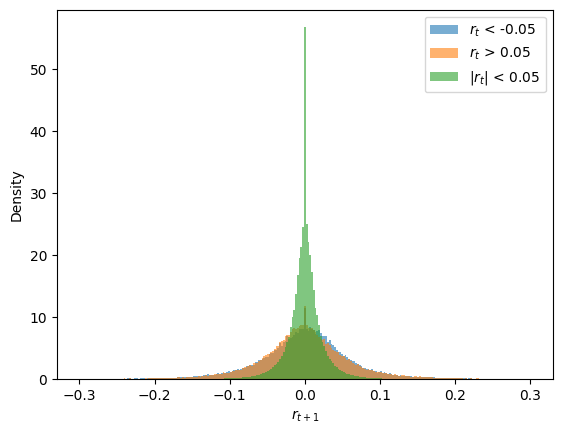

In [5]:
bound = 0.05
lower_returns = data[data["prev_ret_60s"] < -bound]["ret_60s"].dropna()
upper_returns = data[data["prev_ret_60s"] > bound]["ret_60s"].dropna()
middle_returns = data[(data["prev_ret_60s"] < bound) & (data["prev_ret_60s"] > -bound)]["ret_60s"].dropna()
default_returns = data["ret_60s"].dropna()

bins = np.linspace(-0.3, 0.3, 256)

alpha = 0.6
plt.hist(lower_returns, bins=bins, density=True, alpha=alpha, label=f"$r_t$ < -{bound}")
plt.hist(upper_returns, bins=bins, density=True, alpha=alpha, label=f"$r_t$ > {bound}")
plt.hist(middle_returns, bins=bins, density=True, alpha=alpha, label=f"|$r_t$| < {bound}")
plt.legend()
plt.xlabel("$r_{t+1}$")
plt.ylabel("Density")
plt.show()


In [6]:
cond_returns = [("lower", lower_returns), ("upper", upper_returns), ("middle", middle_returns)]
for name, returns in cond_returns:
    normalized_returns = returns / np.std(returns)
    print(name, f"std: {np.std(returns):.3f}", f"skewness: {np.mean(normalized_returns ** 3):.3f}", f"kurtosis: {np.mean(normalized_returns ** 4):.3f}")


lower std: 1.791 skewness: 266.157 kurtosis: 73976.317
upper std: 0.586 skewness: -130.407 kurtosis: 17678.647
middle std: 0.705 skewness: 580.312 kurtosis: 349333.405


0.0006410758495269497


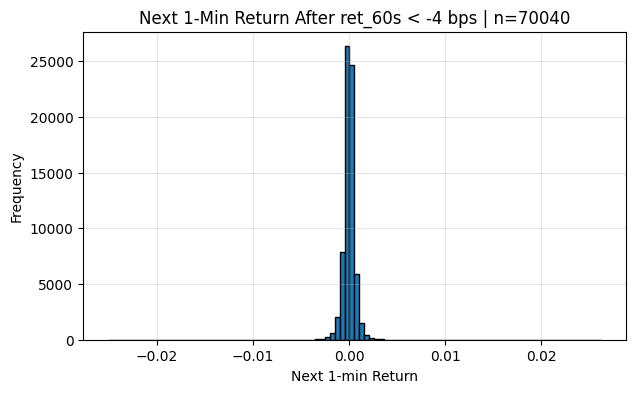

In [ ]:
lb = -0.0004
lower_returns = data[data["prev_ret_60s"] < lb]["ret_60s"].dropna()

plt.figure(figsize=(7, 4))
plt.hist(next_returns, bins=100, edgecolor="black")
plt.title(f"Next 1-Min Return After ret_60s < {lb*1e4:.0f} bps | n={len(next_returns)}")
plt.xlabel("Next 1-min Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

0.0006197776714850837


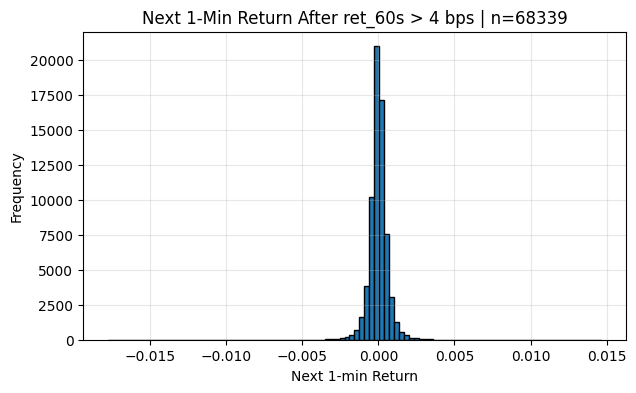

In [31]:
ub = 0.0004
next_returns = data[data["prev_ret_60s"] > ub]["ret_60s"].dropna()
print(np.std(next_returns))

plt.figure(figsize=(7, 4))
plt.hist(next_returns, bins=100, edgecolor="black")
plt.title(f"Next 1-Min Return After ret_60s > {ub*1e4:.0f} bps | n={len(next_returns)}")
plt.xlabel("Next 1-min Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

0.00025745594509798476


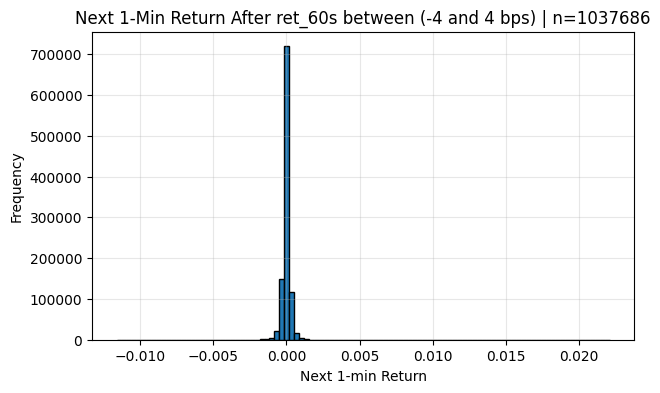

In [32]:
import matplotlib.pyplot as plt

next_returns = data[(data["prev_ret_60s"] < ub) & (data["prev_ret_60s"] > lb)]["ret_60s"].dropna()
print(np.std(next_returns))
plt.figure(figsize=(7, 4))
plt.hist(next_returns, bins=100, edgecolor="black")
plt.title(f"Next 1-Min Return After ret_60s between ({lb*1e4:.0f} and {ub*1e4:.0f} bps) | n={len(next_returns)}")
plt.xlabel("Next 1-min Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()